In [5]:
# !wget -O simhei.ttf "https://www.wfonts.com/download/data/2014/06/01/simhei/chinese.simhei.ttf"
import matplotlib.pyplot as plt
import matplotlib as mpl
zhfont = mpl.font_manager.FontProperties(fname='simhei.ttf')
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [2]:
# 注意此代码如果想在自己的笔记本上运行，需要加上 --num_workers 0  取消多进程
# ETTh1_S_48_48_24
!python -u run.py --is_training 1 --root_path ./dataset/ETT-small/ --data_path ETTh1.csv --model_id ETTh1_48_24 --model Autoformer --data ETTh1 --features S --seq_len 48 --label_len 48 --pred_len 24 --e_layers 2 --d_layers 1 --factor 3 --enc_in 1 --dec_in 1 --c_out 1 --des 'Exp' --itr 1 --inverse --loss_way 0 --scaler_way 0

Args in experiment:
Namespace(activation='gelu', batch_size=32, bucket_size=4, c_out=1, checkpoints='./checkpoints/', d_ff=2048, d_layers=1, d_model=512, data='ETTh1', data_path='ETTh1.csv', dec_in=1, des='Exp', devices='0,1,2,3', distil=True, do_predict=False, dropout=0.05, e_layers=2, embed='timeF', enc_in=1, factor=3, features='S', freq='h', gpu=0, inverse=True, is_training=1, itr=1, label_len=48, learning_rate=0.0001, loss='mse', loss_alpha=1, loss_way=0, lradj='type1', model='Autoformer', model_id='ETTh1_48_24', moving_avg=25, n_hashes=4, n_heads=8, num_workers=10, output_attention=False, patience=3, pred_len=24, root_path='./dataset/ETT-small/', scaler_way=0, seq_len=48, target='OT', train_epochs=10, use_amp=False, use_gpu=True, use_multi_gpu=False)
Use GPU: cuda:0
>>>>>>>start training : ETTh1_48_24_Autoformer_ETTh1_ftS_sl48_ll48_pl24_dm512_nh8_el2_dl1_df2048_fc3_ebtimeF_dtTrue_Exp_0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 8569
val 2857
test 2857
	iters: 100, epoch: 1 | loss: 8.5786896


In [3]:
#打印结果
import numpy as np

setting = "ETTh1_48_24_Autoformer_ETTh1_ftS_sl48_ll48_pl24_dm512_nh8_el2_dl1_df2048_fc3_ebtimeF_dtTrue_Exp_0"
np.set_printoptions(precision=3) #设置小数位置为3位

input = np.load('./results/'+setting+'/input.npy')
print("输入的数据为：{}".format(input[0,:,0]))

pred = np.load('./results/'+setting+'/pred.npy')
print("预测的结果为：{}".format(pred[0,:,0]))

true = np.load('./results/'+setting+'/true.npy')
print("真实的结果为：{}".format(true[0,:,0]))

metrics = np.load('./results/'+setting+'/metrics.npy')
print("mae, mse, rmse, mape, mspe分别为：{}".format(metrics))

输入的数据为：[ 9.778  9.778  9.708  9.919  9.426  8.934  9.638  8.09   8.582  9.638
 10.904 10.974 11.396 12.522 12.874 12.381 13.647 13.436 12.1   11.959
 12.029 11.537 11.537 10.904 10.763 11.256 11.889 12.381 11.326 10.622
  9.497  9.215  9.426  9.356 10.763 11.044 11.256 11.256 11.396 11.185
 11.326 11.467 10.552 10.271  9.708  8.723  8.864  9.004]
预测的结果为：[ 7.723  7.987  8.064  8.169  8.302  8.292  8.628  9.036  9.227  9.686
 10.278 10.74  10.996 10.573 10.241  9.92   9.78   9.498  9.358  9.072
  8.979  8.833  8.644  8.319]
真实的结果为：[ 9.215  9.145  9.497  9.075  8.723  8.934  8.864  8.864  9.426  9.426
  9.708  9.849 10.06  11.678 12.17  11.185 11.044 11.607 10.974 11.396
 10.833 10.833 10.341  9.286]
mae, mse, rmse, mape, mspe分别为：[1.894 6.099 2.47    inf   inf]


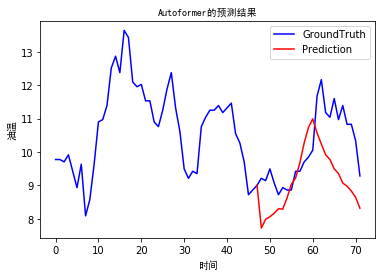

In [4]:
#画图
x1 = np.arange(48+24)
x2 = np.arange(47,48+24)
y_t = np.concatenate((input[0,:,0],true[0,:,0]))
y_p = np.concatenate(([input[0,-1,0]],pred[0,:,0]))

plt.plot(x1,y_t,color='b')
plt.plot(x2,y_p,color='r')
plt.xlabel(u'时间',fontproperties=zhfont)
plt.ylabel(u'油温',fontproperties=zhfont)
plt.legend(('GroundTruth', 'Prediction'), loc='upper right')
plt.title(u'Autoformer的预测结果',fontproperties=zhfont)

plt.savefig('./Autoformer_ETTh1_S_48_48_24.png')
plt.show()

In [7]:
# mydata0_S_48_48_24
!python run.py --is_training 1 --data custom --root_path ./../ --data_path mydata0.csv --model_id mydata0_S_48_48_24 --model Autoformer --features S --seq_len 48 --label_len 48 --pred_len 24 --e_layers 2 --d_layers 1 --enc_in 1 --dec_in 1 --c_out 1 --des 'Exp' --itr 3 --target 'y' --freq d --batch_size 32 --inverse --scaler_way 1 --moving_avg 1

Args in experiment:
Namespace(activation='gelu', batch_size=32, bucket_size=4, c_out=1, checkpoints='./checkpoints/', d_ff=2048, d_layers=1, d_model=512, data='custom', data_path='mydata0.csv', dec_in=1, des='Exp', devices='0,1,2,3', distil=True, do_predict=False, dropout=0.05, e_layers=2, embed='timeF', enc_in=1, factor=1, features='S', freq='d', gpu=0, inverse=True, is_training=1, itr=3, label_len=48, learning_rate=0.0001, loss='mse', loss_alpha=1, loss_way=0, lradj='type1', model='Autoformer', model_id='mydata0_S_48_48_24', moving_avg=1, n_hashes=4, n_heads=8, num_workers=10, output_attention=False, patience=3, pred_len=24, root_path='./../', scaler_way=1, seq_len=48, target='y', train_epochs=10, use_amp=False, use_gpu=True, use_multi_gpu=False)
Use GPU: cuda:0
>>>>>>>start training : mydata0_S_48_48_24_Autoformer_custom_ftS_sl48_ll48_pl24_dm512_nh8_el2_dl1_df2048_fc1_ebtimeF_dtTrue_Exp_0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 6929
val 977
test 1977
	iters: 100, epoch: 1 | loss: 51881.7734

Updating learning rate to 0.0001
	iters: 100, epoch: 2 | loss: 47255.9687500
	speed: 0.0905s/iter; left time: 167.0284s
	iters: 200, epoch: 2 | loss: 46747.3867188
	speed: 0.0458s/iter; left time: 79.8976s
Epoch: 2 cost time: 9.65257215499878
Epoch: 2, Steps: 216 | Train Loss: 43560.7697121 Vali Loss: 1633.0366211 Test Loss: 1633.0361328
EarlyStopping counter: 1 out of 3
Updating learning rate to 5e-05
	iters: 100, epoch: 3 | loss: 40359.4218750
	speed: 0.0843s/iter; left time: 137.3106s
	iters: 200, epoch: 3 | loss: 38960.3203125
	speed: 0.0459s/iter; left time: 70.1548s
Epoch: 3 cost time: 9.929142236709595
Epoch: 3, Steps: 216 | Train Loss: 39414.7173575 Vali Loss: 305.0575867 Test Loss: 305.0576477
EarlyStopping counter: 2 out of 3
Updating learning rate to 2.5e-05
	iters: 100, epoch: 4 | loss: 35627.0820312
	speed: 0.0858s/iter; left time: 121.2251s
	iters: 200, epoch: 4 | loss: 35478.7500000
	speed: 0.0433s/iter; left time: 56.8871s
Epoch: 4 cost time: 10.42098069190979
Epoch: 4,

In [12]:
#打印结果
import numpy as np

setting = "mydata0_S_48_48_24_Autoformer_custom_ftS_sl48_ll48_pl24_dm512_nh8_el2_dl1_df2048_fc1_ebtimeF_dtTrue_Exp_0"
np.set_printoptions(precision=3) #设置小数位置为3位

input = np.load('./results/'+setting+'/input.npy')
print("输入的数据为：{}".format(input[0,:,0]))

pred = np.load('./results/'+setting+'/pred.npy')
print("预测的结果为：{}".format(pred[0,:,0]))

true = np.load('./results/'+setting+'/true.npy')
print("真实的结果为：{}".format(true[0,:,0]))

metrics = np.load('./results/'+setting+'/metrics.npy')
print("mae, mse, rmse, mape, mspe分别为：{}".format(metrics))

输入的数据为：[7953. 7954. 7955. 7956. 7957. 7958. 7959. 7960. 7961. 7962. 7963. 7964.
 7965. 7966. 7967. 7968. 7969. 7970. 7971. 7972. 7973. 7974. 7975. 7976.
 7977. 7978. 7979. 7980. 7981. 7982. 7983. 7984. 7985. 7986. 7987. 7988.
 7989. 7990. 7991. 7992. 7993. 7994. 7995. 7996. 7997. 7998. 7999. 8000.]
预测的结果为：[8002.79  8011.094 8011.094 8011.094 8011.094 8011.094 8011.094 8011.094
 8011.094 8011.094 8011.094 8011.094 8011.094 8011.094 8011.094 8011.094
 8011.094 8011.094 8011.094 8011.094 8018.296 8025.486 8024.372 8023.259]
真实的结果为：[8001. 8002. 8003. 8004. 8005. 8006. 8007. 8008. 8009. 8010. 8011. 8012.
 8013. 8014. 8015. 8016. 8017. 8018. 8019. 8020. 8021. 8022. 8023. 8024.]
mae, mse, rmse, mape, mspe分别为：[4.174e+00 2.480e+01 4.980e+00 4.663e-04 3.108e-07]


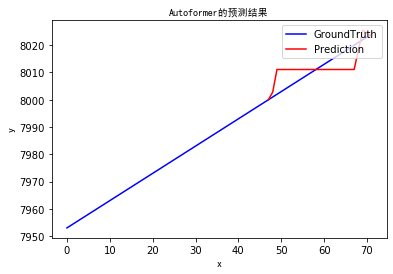

In [13]:
#画图
x1 = np.arange(48+24)
x2 = np.arange(47,48+24)
y_t = np.concatenate((input[0,:,0],true[0,:,0]))
y_p = np.concatenate(([input[0,-1,0]],pred[0,:,0]))

plt.plot(x1,y_t,color='b')
plt.plot(x2,y_p,color='r')
plt.xlabel(u'x',fontproperties=zhfont)
plt.ylabel(u'y',fontproperties=zhfont)
plt.legend(('GroundTruth', 'Prediction'), loc='upper right')
plt.title(u'Autoformer的预测结果',fontproperties=zhfont)

plt.savefig('./Autoformer_mydata0_S_48_48_24.png')
plt.show()